In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1jMVvdsT2jjaKnH_8wy_Z_yk31kT6OXqr", index_col=None)
df.drop(columns=['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 
                 'activities', 'nursery', 'higher', 'internet', 'romantic', 'freetime', 'Dalc', 'absences', 'Mjob', 'Fjob', 'reason', 'guardian'], inplace=True)
df

,famrel,goout,Walc,health,G1,G2,G3
0,4,4,1,3,5,6,6
1,5,3,1,3,5,5,6
2,4,2,3,3,7,8,10
3,3,2,1,5,15,14,15
4,4,2,2,5,6,10,10
...,...,...,...,...,...,...,...
390,5,4,5,4,9,9,9
391,2,5,4,2,14,16,16
392,5,3,3,3,10,8,7
393,4,1,4,5,11,12,10


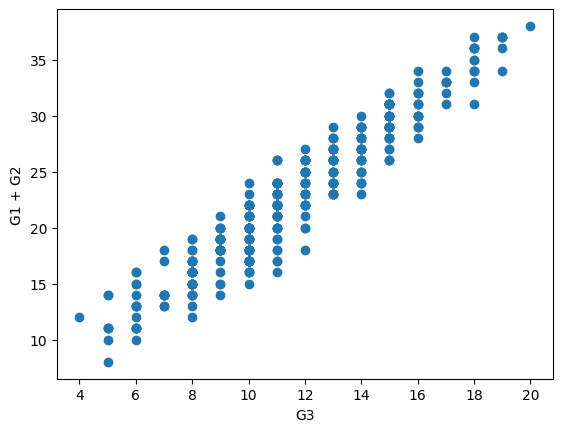

In [3]:
df = df[df["G3"] != 0]
plt.scatter(df["G3"], df["G1"] + df["G2"])
plt.xlabel("G3")
plt.ylabel("G1 + G2")    
plt.show()

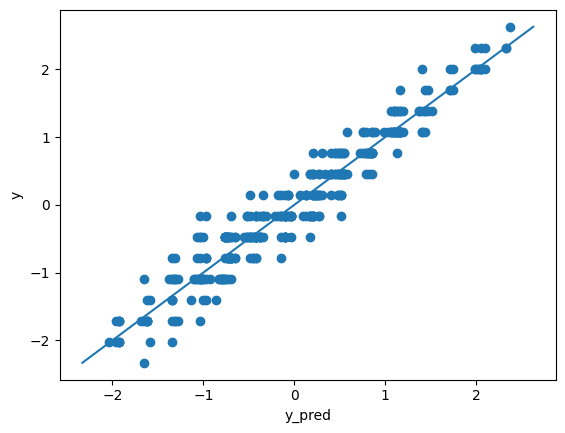

y = 0.0000 + 0.1121G1 + 0.8645G2


0.9346934634836721

In [4]:
x = df[["G1", "G2"]]
y = df["G3"]
x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()
x = np.column_stack((np.ones(len(x)), x))
theta = np.linalg.inv(x.T @ x) @ x.T @ y

y_pred = theta[0] + theta[1] * x[:, 1] + theta[2] * x[:, 2]
plt.scatter(y_pred, y)
plt.xlabel("y_pred")
plt.ylabel("y")
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.show()
print(f"y = {theta[0]:.4f} + {theta[1]:.4f}G1 + {theta[2]:.4f}G2")
r2_score(y, y_pred)

In [5]:
binary_cols = df.select_dtypes(include=['str']).columns

for col in binary_cols:
    unique = df[col].unique()
    if len(unique) == 2:
        df[col] = df[col].replace({unique[0]: 0, unique[1]: 1})
        

binary_cols = [col for col in binary_cols if df[col].nunique() >= 3]
numeric_cols = df.select_dtypes(exclude=['str']).columns

df = pd.get_dummies(df, columns=binary_cols, drop_first=True)
df = df.astype(float)
for col in numeric_cols:
    mean = df[col].mean()
    std = df[col].std()
    df[col] = (df[col] - mean) / std

In [6]:
X = df.drop("G3", axis = 1)
Y = df["G3"]
X = (X - X.mean()) / X.std()
Y = (Y - Y.mean()) / Y.std()

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.4, random_state = 7, shuffle = True)
x_train, x_test, y_train, y_test = x_train.reset_index(drop=True), x_test.reset_index(drop=True), y_train.reset_index(drop=True), y_test.reset_index(drop=True)
x = np.concatenate((np.ones((x_train.shape[0], 1)), x_train.values.reshape(-1, x_train.shape[1])) , axis = 1)
y = y_train.values.reshape(-1,1)

model = LassoCV(cv = 10, random_state = 7)
model.fit(x_train, y_train)

for weight, feat in zip(model.coef_, x_train.columns):
    print(f"{feat}: {weight}")
r2_score(y_train, model.predict(x_train))


famrel: 0.04382792162497114
goout: -0.039694372963637446
Walc: -0.010501666220461767
health: -0.038255152193731344
G1: 0.10121977033592204
G2: 0.8736836198885569


0.9479949335833767

In [7]:
df2 = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred.reshape(-1,)
})
r2_score(y_test, y_pred)

ValueError: array length 357 does not match index length 143